In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input

# 1. Setup Column Names
col_names = ['id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f's{i}' for i in range(1, 22)]

# 2. Load FD003 (or FD001)
train_df = pd.read_csv('CMAPSSData/train_FD003.txt', sep=r'\s+', header=None, names=col_names)
test_df = pd.read_csv('CMAPSSData/test_FD003.txt', sep=r'\s+', header=None, names=col_names)
true_rul = pd.read_csv('CMAPSSData/RUL_FD003.txt', sep=r'\s+', header=None, names=['RUL'])

# Instead of: train_df['RUL'] = max_cycle - train_df['cycle']
# Use this:
MAX_RUL = 125
train_df['RUL'] = train_df.groupby('id')['cycle'].transform('max') - train_df['cycle']
train_df['RUL'] = train_df['RUL'].clip(upper=MAX_RUL)

In [3]:
# Select relevant sensors (exclude constant ones)
relevant_sensors = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
features = ['cycle', 'setting1', 'setting2'] + relevant_sensors

# Scaling
scaler = MinMaxScaler()
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features])

# Sequence Generation Function
def gen_sequence(id_df, seq_length, seq_cols):
    data_matrix = id_df[seq_cols].values
    num_elements = data_matrix.shape[0]
    for start, stop in zip(range(0, num_elements-seq_length), range(seq_length, num_elements)):
        yield data_matrix[start:stop, :]

def gen_labels(id_df, seq_length, label_col):
    data_matrix = id_df[label_col].values
    num_elements = data_matrix.shape[0]
    return data_matrix[seq_length:num_elements, :]

sequence_length = 30

# Prepare Training Data
X_train = np.concatenate([list(gen_sequence(train_df[train_df['id']==id], sequence_length, features)) for id in train_df['id'].unique()])
y_train = np.concatenate([gen_labels(train_df[train_df['id']==id], sequence_length, ['RUL']) for id in train_df['id'].unique()])

# Prepare Test Data (only the last sequence per engine)
X_test = np.array([test_df[test_df['id']==id][features].values[-sequence_length:] for id in test_df['id'].unique() if len(test_df[test_df['id']==id]) >= sequence_length])
y_test = true_rul.values

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

def build_rnn_model(window_size, feature_count):
    model = Sequential([
        Input(shape=(window_size, feature_count)),
        
        SimpleRNN(64, return_sequences=True, activation='tanh'),
        Dropout(0.2),
        
        SimpleRNN(32, return_sequences=False, activation='tanh'),
        Dropout(0.2),
        
        Dense(32, activation='relu'),
        Dense(1) 
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_rnn = build_rnn_model(sequence_length, len(features))
model_rnn.summary()

2026-04-29 10:29:48.765105: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-29 10:29:48.765155: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-29 10:29:48.765174: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-29 10:29:48.765207: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-29 10:29:48.765237: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 64)         │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,441 (36.88 KB)

 Trainable params: 9,441 (36.88 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_rnn = model_rnn.fit(
    X_train, y_train, 
    epochs=40, 
    batch_size=64, 
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40


2026-04-29 10:30:24.423207: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


272/272 ━━━━━━━━━━━━━━━━━━━━ 145s 530ms/step - loss: 4739.7798 - mae: 59.3455 - val_loss: 1821.6917 - val_mae: 38.9308
Epoch 2/40
272/272 ━━━━━━━━━━━━━━━━━━━━ 154s 565ms/step - loss: 1783.7268 - mae: 37.3646 - val_loss: 1724.2366 - val_mae: 36.7269
Epoch 3/40
272/272 ━━━━━━━━━━━━━━━━━━━━ 165s 608ms/step - loss: 1270.3035 - mae: 29.9242 - val_loss: 376.3700 - val_mae: 15.9591
Epoch 4/40
272/272 ━━━━━━━━━━━━━━━━━━━━ 163s 599ms/step - loss: 443.2665 - mae: 16.1753 - val_loss: 435.8485 - val_mae: 16.1143
Epoch 5/40
272/272 ━━━━━━━━━━━━━━━━━━━━ 163s 599ms/step - loss: 404.1758 - mae: 15.3716 - val_loss: 400.0043 - val_mae: 15.3355
Epoch 6/40
272/272 ━━━━━━━━━━━━━━━━━━━━ 160s 589ms/step - loss: 389.7305 - mae: 14.9715 - val_loss: 309.7362 - val_mae: 13.1617
Epoch 7/40
272/272 ━━━━━━━━━━━━━━━━━━━━ 162s 597ms/step - loss: 383.6430 - mae: 14.7770 - val_loss: 262.5413 - val_mae: 12.0712
Epoch 8/40
272/272 ━━━━━━━━━━━━━━━━━━━━ 160s 589ms/step - loss: 349.0510 - mae: 14.1426 - val_loss: 284.3726 -

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step
Standalone RNN RMSE: 18.18


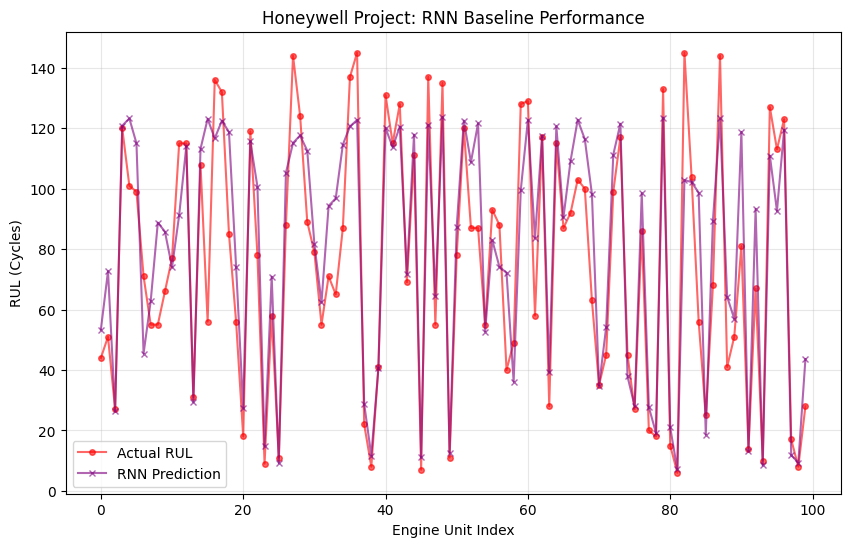

In [7]:
# 1. Predict on Test Set
y_pred_rnn = model_rnn.predict(X_test)
rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
print(f"Standalone RNN RMSE: {rmse_rnn:.2f}")

# 2. Plot Actual vs Predicted for RNN
plt.figure(figsize=(10, 6))
plt.plot(y_test, color='red', label='Actual RUL', marker='o', markersize=4, alpha=0.6)
plt.plot(y_pred_rnn, color='purple', label='RNN Prediction', marker='x', markersize=4, alpha=0.6)
plt.title('Honeywell Project: RNN Baseline Performance')
plt.xlabel('Engine Unit Index')
plt.ylabel('RUL (Cycles)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

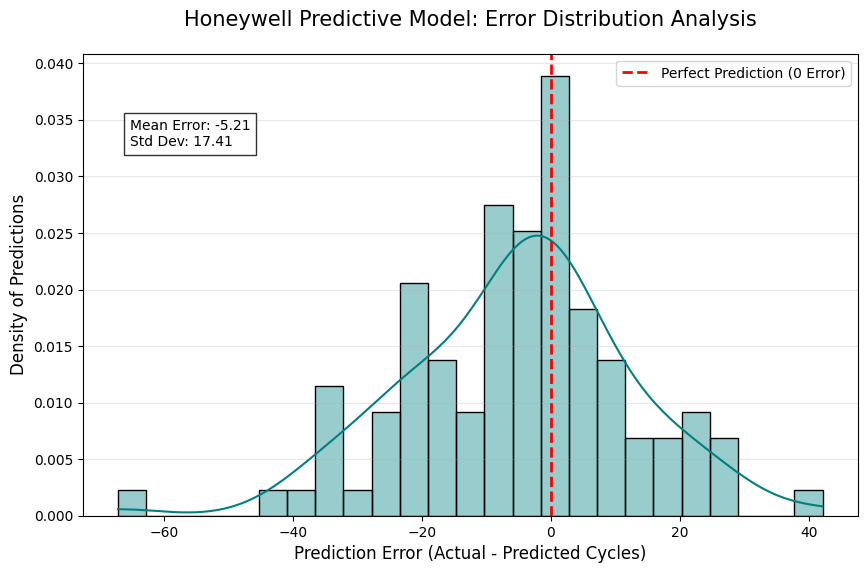

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

errors = y_test.flatten() - y_pred_rnn.flatten() 

plt.figure(figsize=(10, 6))

sns.histplot(errors, kde=True, color='teal', bins=25, stat="density", alpha=0.4)

plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction (0 Error)')

plt.title('Honeywell Predictive Model: Error Distribution Analysis', fontsize=15, pad=20)
plt.xlabel('Prediction Error (Actual - Predicted Cycles)', fontsize=12)
plt.ylabel('Density of Predictions', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

mean_err = errors.mean()
std_err = errors.std()
plt.text(plt.xlim()[0]*0.9, plt.ylim()[1]*0.8, 
         f'Mean Error: {mean_err:.2f}\nStd Dev: {std_err:.2f}', 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

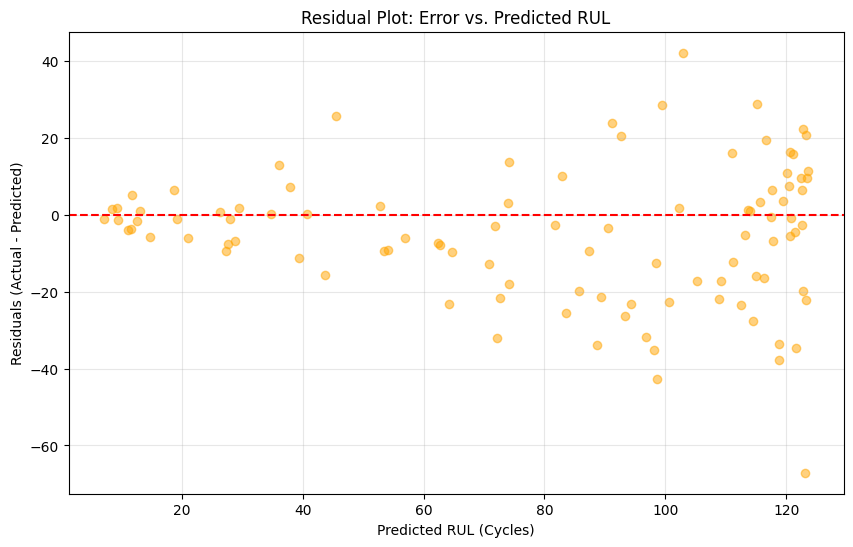

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_rnn, errors, alpha=0.5, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot: Error vs. Predicted RUL')
plt.xlabel('Predicted RUL (Cycles)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(alpha=0.3)
plt.show()